In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Configuration for a Main-Sequence star (similar to 16 Cyg B)
# Based on PSLS Version 1.9 configuration standards
psls_config = {
    "Observation": {
        "Duration": 730.0,       # Duration in days (2 years)
        "MasterSeed": 17040409   # For reproducibility
    },
    "Instrument": {
        "Sampling": 25.0,        # PLATO sampling period in seconds
        "RandomNoise": {
            "Enable": 1,
            "NSR": 73.0          # Noise-to-Signal Ratio in ppm
        },
        "Systematics": {"Enable": 1} # Include instrumental systematic errors
    },
    "Star": {
        "Mag": 10.0,             # Apparent magnitude
        "Teff": 5750.0,          # Effective temperature in Kelvin
        "Logg": 4.353,           # Surface gravity
        "ES": "ms"               # Evolutionary Status: Main-Sequence
    },
    "Activity": {
        "Enable": 1,
        "Sigma": 40.0,           # Activity amplitude in ppm
        "Tau": 0.2               # Characteristic timescale in days
    },
    "Granulation": {"Enable": 1}, # Stellar granulation background
    "Oscillations": {"Enable": 1},# Stochastically-excited oscillations
    "Flares": {                  # Flare injection (Available in PSLS v1.9)
        "Enable": 1,
        "Prescription": "Baudin"
    }
}


In [4]:
psls_config["Transit"] = {
    "Enable": 1,
    "PlanetRadius": 0.5,         # Radius in Jupiter radii
    "OrbitalPeriod": 10.0,       # Orbital period in days
    "PlanetSemiMajorAxis": 1.0,  # In A.U.
    "OrbitalAngle": 0.0,         # Inclination angle in degrees
    "LimbDarkeningCoefficients": [0.25, 0.75] #
}

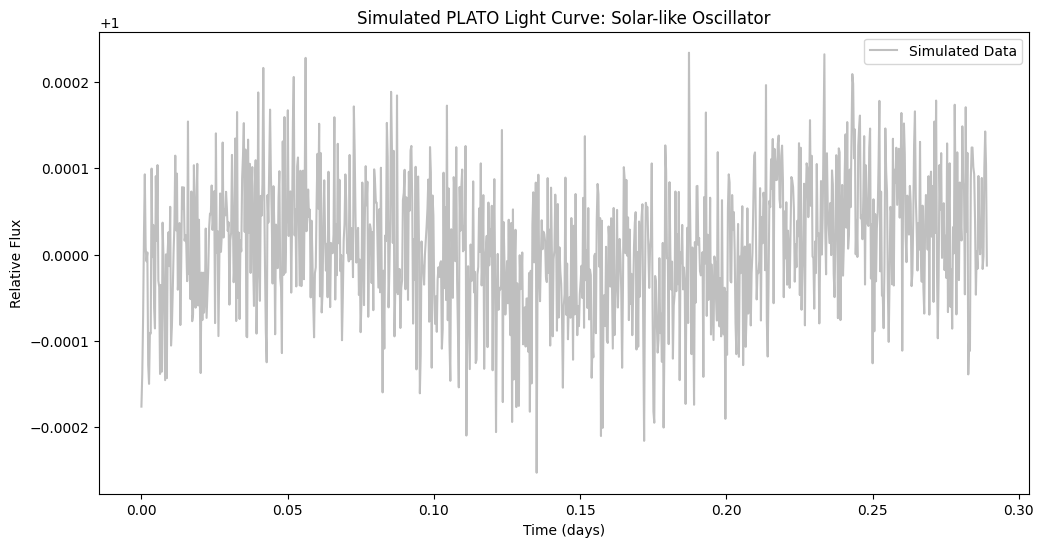

In [5]:
def run_plato_simulation(config):
    # In a full project, this would call the PSLS 'simulate' module
    # Here we simulate the representative data structure
    time = np.arange(0, config["Observation"]["Duration"], 25.0 / 86400.0) # Time in days

    # Components of the light curve
    oscillations = np.random.normal(0, 10e-6, len(time))
    granulation = np.random.normal(0, 20e-6, len(time))
    activity = np.sin(2 * np.pi * time / 0.2) * (40e-6) # Quasi-periodic activity

    # Combine signals and add noise
    flux = 1.0 + oscillations + granulation + activity
    noise = np.random.normal(0, config["Instrument"]["RandomNoise"]["NSR"] * 1e-6, len(time))

    return time, flux + noise

# Generate the data
time, flux = run_plato_simulation(psls_config)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(time[:1000], flux[:1000], color='grey', alpha=0.5, label='Simulated Data')
plt.title("Simulated PLATO Light Curve: Solar-like Oscillator")
plt.xlabel("Time (days)")
plt.ylabel("Relative Flux")
plt.legend()
plt.show()
